In [1]:
#hide
from fastai.vision.all import *

matplotlib.rc('image', cmap='Greys')

# Entrenamiento de un Clasificador de Dígitos

Exploraremos los pasos involucrados en la construcción de un clasificador simple de dígitos. Vamos a:

* Discutir el papel de los *arrays* y tensores, e introducir el concepto de *broadcasting*, una técnica poderosa que hace que las operaciones sobre estas estructuras de datos sean más expresivas.
* Definir una función de pérdida adecuada para esta tarea de clasificación, e introducir el concepto de *mini-lotes* para optimizar el proceso de entrenamiento.
* Explicar las operaciones matemáticas realizadas por una red neuronal básica.

Al final, combinaremos todas estas piezas para crear un modelo capaz de clasificar imágenes de dígitos.

## Clasificación de Imágenes

Construiremos un clasificador de imágenes para explorar los pasos clave y las técnicas en el flujo de trabajo del aprendizaje profundo.

En la clasificación de imágenes, nuestro objetivo es asignar una etiqueta $ y $ a cada imagen $ X $ a partir de un conjunto de clases posibles $ C $, donde $ C $ puede ser categorías como razas de mascotas, estados de enfermedad o tipos de células. Matemáticamente, podemos representarlo como una función $ f: X \rightarrow y $, que asigna cada imagen a una etiqueta de clase. Esto se logra entrenando un modelo para minimizar una función de pérdida que cuantifica la diferencia entre las etiquetas predichas y las verdaderas.

En la clasificación binaria (por ejemplo, identificar la presencia o ausencia de una enfermedad), la salida es una única puntuación de probabilidad $ p $, con $ y = 1 $ si $ p \geq 0.5 $ y $ y = 0 $ en caso contrario. Para la clasificación multiclase (por ejemplo, identificar diferentes tipos de tumores), el modelo produce un vector de probabilidades $ \mathbf{p} = [p_1, p_2, \dots, p_k] $ para cada clase $ k $, donde $ \sum_{i=1}^k p_i = 1 $.

## Píxeles: Las Bases de la Visión por Computador

Nuestro objetivo es construir un modelo que pueda clasificar una imagen como un "3" o un "7". Para empezar, descargamos una muestra del conjunto de datos MNIST que incluye imágenes de solo estos dígitos.

In [2]:
# Load the MNIST sample dataset
path = untar_data(URLs.MNIST_SAMPLE)

# Check the directory contents
path.ls()

(#3) [Path('C:/Users/biagi/.fastai/data/mnist_sample/labels.csv'),Path('C:/Users/biagi/.fastai/data/mnist_sample/train'),Path('C:/Users/biagi/.fastai/data/mnist_sample/valid')]

In [3]:
(path/'train').ls()

(#2) [Path('C:/Users/biagi/.fastai/data/mnist_sample/train/3'),Path('C:/Users/biagi/.fastai/data/mnist_sample/train/7')]

En este conjunto de datos, "3" y "7" son las *etiquetas* o *objetivos*.

In [4]:
# Get the path for the images of "3"
threes = (path/'train'/'3').ls().sorted()

# Open and display an example image
im3_path = threes[1]
im3 = Image.open(im3_path)
im3.show()

En Python, las imágenes suelen estar representadas por la clase `Image` de la *Python Imaging Library* (PIL). Convertir una imagen a un formato numérico, como un *array* de NumPy o un tensor de PyTorch, nos permite realizar operaciones matemáticas directamente sobre los datos de la imagen.


In [5]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)


Cada píxel de la imagen tiene un valor entre 0 y 255, donde 0 representa negro y 255 blanco, con tonos de gris en medio.

In [6]:
tensor(im3)[4:10,4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

## Similitud de Píxeles

Como modelo básico, calculamos los valores promedio de píxeles de todas las imágenes de "3" y "7" por separado. Esto nos da una versión "ideal" de cada dígito, que podemos usar para comparar. Para clasificar una imagen, comprobamos con cuál de estas representaciones ideales se parece más.

<Axes: >

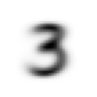

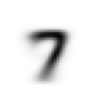

In [7]:
# Load images of 3s and 7s as tensors
three_tensors = [tensor(Image.open(o)) for o in threes]
seven_tensors = [tensor(Image.open(o)) for o in (path/'train'/'7').ls().sorted()]

# Stack tensors and normalize
stacked_threes = torch.stack(three_tensors).float()/255
stacked_sevens = torch.stack(seven_tensors).float()/255

# Calculate the average image (mean) for each digit
mean3 = stacked_threes.mean(0)
mean7 = stacked_sevens.mean(0)

# Display the "ideal" 3 and 7
show_image(mean3)
show_image(mean7)

La distancia puede calcularse con:

* Diferencia Absoluta Media (norma L1)
* Error Cuadrático Medio (norma L2)

Si la distancia al "3 ideal" es menor, clasificamos la imagen como un 3; en caso contrario, como un 7.


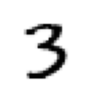

In [9]:
a_3 = stacked_threes[1]
show_image(a_3);

In [10]:
dist_3_abs = (a_3 - mean3).abs().mean()
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_3_abs,dist_3_sqr

(tensor(0.1114), tensor(0.2021))

In [11]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

> Intuitivamente, la diferencia entre la norma L1 y el error cuadrático medio (MSE) es que el segundo penaliza más fuertemente los errores grandes, mientras que es más indulgente con los errores pequeños.

## Cálculo de Métricas

Para evaluar el rendimiento de nuestro modelo necesitamos una forma de medir qué tan bien está funcionando. A esta medida se le llama **métrica**.
Las métricas se calculan comparando las predicciones del modelo con las etiquetas reales en el conjunto de datos. Para tareas de clasificación como esta, una métrica común es la **exactitud** (accuracy).

En nuestro caso, queremos determinar si cada imagen se clasifica correctamente como un "3" o un "7". La exactitud para esta tarea se puede calcular de la siguiente manera:

1. Calcular la predicción del modelo para cada imagen.
2. Verificar si la predicción coincide con la etiqueta real.
3. Promediar estos resultados (correctos/incorrectos) en todo el conjunto de datos.

Tenemos dos conjuntos de validación: uno para los 3 y otro para los 7. 

In [12]:
# Load and normalize validation sets
valid_3_tens = torch.stack([tensor(Image.open(o)) for o in (path/'valid'/'3').ls()]).float()/255
valid_7_tens = torch.stack([tensor(Image.open(o)) for o in (path/'valid'/'7').ls()]).float()/255

# Check shapes of validation tensors
valid_3_tens.shape, valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

Cada tensor tiene la forma `[número_de_imágenes, alto, ancho]`, donde:

* `valid_3_tens` contiene 1.010 imágenes de 3.
* `valid_7_tens` contiene 1.028 imágenes de 7.

Esto nos permite probar nuestra función en ambas categorías y calcular la exactitud considerando todas las imágenes de validación.

### Tensores en PyTorch y Broadcasting

Los tensores son arreglos multidimensionales que permiten cálculos rápidos en PyTorch. A diferencia de las listas en Python, que son más lentas, los tensores posibilitan operaciones matemáticas a gran escala de forma eficiente.

El **broadcasting** es una técnica que permite realizar operaciones entre tensores de diferentes formas. Por ejemplo, restar un “dígito ideal” a cada imagen de un lote es posible porque PyTorch “expande” automáticamente el dígito ideal para que coincida con el tamaño del lote.

### Definiendo una Función de Distancia con Broadcasting

Para clasificar una imagen necesitamos calcular su “distancia” al “3 ideal” y al “7 ideal” (los promedios calculados anteriormente). Una función útil para esto es el **error absoluto medio (MAE)**.

Con broadcasting podemos aplicar el cálculo de distancia a todo un conjunto de imágenes sin necesidad de bucles, lo que hace la computación más rápida y eficiente.


In [13]:
# Define distance function using broadcasting
def mnist_distance(a, b): 
    return (a - b).abs().mean((-1, -2))

# Calculate distance from an example image to the ideal 3
a_3 = valid_3_tens[0]
mnist_distance(a_3, mean3)

tensor(0.1280)

When we pass `valid_3_tens` (all 3s in the validation set) and `mean3` (the ideal 3) to this function, broadcasting automatically expands `mean3` to match the shape of `valid_3_tens`, calculating the distance for each image in the set:

In [14]:
# Calculate distance for all 3s in the validation set
valid_3_dist = mnist_distance(valid_3_tens, mean3)
valid_3_dist.shape  # Output should be a vector of distances

torch.Size([1010])

Broadcasting makes this possible by "stretching" `mean3` to align with each image in `valid_3_tens`, allowing the distance function to operate on all images simultaneously. This avoids the need for loops and makes the computation faster and more efficient.

### Clasificación de una Imagen con Distancia

Para clasificar una nueva imagen, comparamos su distancia con `mean3` y con `mean7`:

* Si está más cerca de `mean3`, la clasificamos como un 3.
* Si está más cerca de `mean7`, la clasificamos como un 7.

In [15]:
# Define classification function
def is_3(x): 
    return mnist_distance(x, mean3) < mnist_distance(x, mean7)

# Test classification on a sample 3
is_3(a_3)

tensor(True)

Podemos aplicar este proceso con broadcasting a todo el conjunto de validación al mismo tiempo.

In [16]:
# Classify all 3s in the validation set
is_3(valid_3_tens)

tensor([ True,  True,  True,  ..., False,  True,  True])


### Cálculo de la Exactitud

Para calcular la exactitud:

* En las imágenes de 3 comprobamos si el modelo predijo correctamente 3 (`True`).
* En las imágenes de 7 comprobamos si el modelo predijo 7 (`False`).

Al calcular la proporción de predicciones correctas en ambos casos y luego promediarlas, obtenemos una medida global del rendimiento del modelo.

In [17]:
# Calculate accuracy for each digit
accuracy_3s = is_3(valid_3_tens).float().mean()  # Accuracy on 3s
accuracy_7s = (1 - is_3(valid_7_tens).float()).mean()  # Accuracy on 7s

# Calculate overall accuracy
overall_accuracy = (accuracy_3s + accuracy_7s) / 2
accuracy_3s, accuracy_7s, overall_accuracy

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

En este ejemplo, `accuracy_3s` y `accuracy_7s` representan la exactitud para clasificar 3 y 7, respectivamente. El promedio de ambas nos da la exactitud total del clasificador.

## Definir una Función de Pérdida

En deep learning, la **función de pérdida** es un componente crítico que guía el proceso de entrenamiento.
Su papel es cuantificar qué tan bien coinciden las predicciones del modelo con los valores objetivo (etiquetas).
El entrenamiento consiste en minimizar esta pérdida de manera progresiva a lo largo de las iteraciones, mejorando así el modelo.

Nuestro objetivo al definir una función de pérdida es que:

1. Produzca un valor que refleje qué tan alejadas están las predicciones de las etiquetas reales.
2. Tenga un gradiente que pueda guiar el proceso de optimización, permitiendo actualizar los parámetros del modelo de forma efectiva.

### ¿Por qué no usar la Exactitud como Función de Pérdida?

Una opción obvia para medir el rendimiento es la **exactitud** (accuracy), que calcula la proporción de predicciones correctas.
Sin embargo, la exactitud no es adecuada como función de pérdida por dos razones principales:

1. **Gradientes planos**: pequeños cambios en los pesos suelen no afectar la exactitud, ya que la predicción permanece igual (correcta o incorrecta). Esto genera regiones de gradientes planos, lo que dificulta la mejora del modelo.
2. **Métrica discreta**: la exactitud es una medida discreta que no captura *cuánto* se equivocó el modelo. Por ejemplo, si la predicción está muy cerca de la respuesta correcta, la exactitud no refleja esta diferencia, pero una buena función de pérdida sí debería hacerlo.

Por ello, la exactitud se usa como **métrica** para evaluar el rendimiento, mientras que la **pérdida** es la que impulsa el aprendizaje del modelo.

### Función de Pérdida para Clasificación Binaria

En nuestra tarea con MNIST buscamos clasificar imágenes como un "3" o un "7".
Podemos tratarlo como un problema de **clasificación binaria**:

* Usamos **1** para las imágenes de "3".
* Usamos **0** para las imágenes de "7".

El objetivo es que el modelo produzca valores cercanos a 1 para los "3" y cercanos a 0 para los "7".
Un enfoque común en clasificación binaria es usar el **error absoluto medio (MAE)** o la **pérdida de entropía cruzada (cross-entropy loss)**.

En este ejemplo, usaremos una función personalizada que mide la distancia entre las predicciones del modelo y las etiquetas reales, asegurando que:

* Para las imágenes de "3" (etiqueta = 1), la predicción esté lo más cerca posible de 1.
* Para las imágenes de "7" (etiqueta = 0), la predicción esté lo más cerca posible de 0.

### Implementar una Función de Pérdida Simple

Supongamos que tenemos tres imágenes con etiquetas `[1, 0, 1]` (representando "3," "7," y "3").
Las predicciones del modelo son `[0.9, 0.4, 0.2]`.
Esto significa:

* El modelo está seguro de que la primera imagen es un 3.
* El modelo está algo seguro de que la segunda es un 7.
* El modelo se equivoca con la tercera, prediciendo 7 en lugar de 3.

Una función de pérdida simple calcularía **qué tan lejos** están estas predicciones de las etiquetas correctas, devolviendo un valor promedio que el modelo debe minimizar durante el entrenamiento.


In [18]:
# Define sample targets and predictions
targets = tensor([1, 0, 1])
predictions = tensor([0.9, 0.4, 0.2])

# Define the MNIST loss function
def mnist_loss(predictions, targets):
    return torch.where(targets == 1, 1 - predictions, predictions).mean()

En esta función:

* `torch.where(targets == 1, 1 - predictions, predictions)` calcula la distancia entre cada predicción y su etiqueta (1 o 0).
* Si `targets == 1` (para un "3"), usamos `1 - prediction` para medir qué tan cerca está de 1.
* Si `targets == 0` (para un "7"), usamos directamente `prediction` para medir qué tan cerca está de 0.
* Finalmente, tomamos la media de todas estas distancias para obtener la **pérdida global**.

Probemos esta función con los valores de ejemplo:

In [19]:
# Calculate loss
mnist_loss(predictions, targets)

tensor(0.4333)

Una pérdida más baja indica que las predicciones están más cerca de los objetivos. Por ejemplo, si cambiamos la predicción de la tercera imagen de `0.2` a `0.8`, que está más cerca del objetivo de 1, la pérdida disminuye:


In [20]:
mnist_loss(tensor([0.9, 0.4, 0.8]), targets)

tensor(0.2333)

### Asegurando predicciones entre 0 y 1 con la función Sigmoide

Para usar la función de pérdida de manera efectiva, necesitamos asegurarnos de que las predicciones caigan entre 0 y 1. Esto se puede lograr usando la **función sigmoide**, definida como:

$$
\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}
$$

La función sigmoide comprime cualquier entrada a un rango entre 0 y 1, lo que la hace perfecta para tareas de clasificación binaria. En PyTorch, podemos usar `torch.sigmoid` para este propósito.


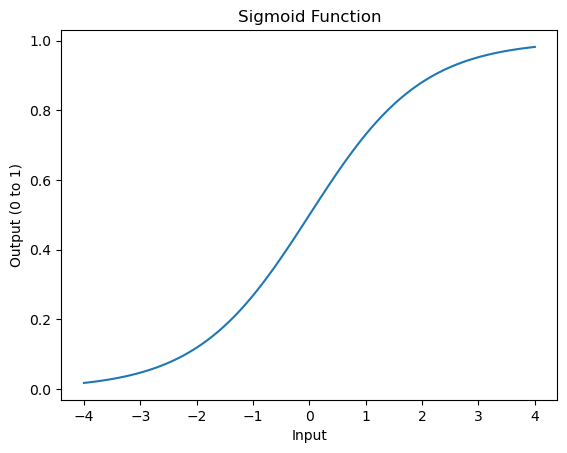

In [21]:
# Define the sigmoid function (PyTorch version)
def sigmoid(x): return 1 / (1 + torch.exp(-x))

# Plot the sigmoid function
import matplotlib.pyplot as plt
x = torch.linspace(-4, 4, 100)
plt.plot(x, sigmoid(x))
plt.title("Sigmoid Function")
plt.xlabel("Input")
plt.ylabel("Output (0 to 1)")
plt.show()

La función sigmoide asigna cualquier entrada real a un valor entre 0 y 1, lo que significa que las predicciones ahora pueden representar probabilidades.

### Actualizando la función de pérdida con Sigmoide

Podemos actualizar nuestra función `mnist_loss` para aplicar primero la sigmoide a las predicciones. Esto asegura que la función de pérdida funcione incluso si las salidas del modelo no están restringidas entre 0 y 1.

In [22]:
# Updated MNIST loss function with sigmoid
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets == 1, 1 - predictions, predictions).mean()


### ¿Por qué necesitamos una función de pérdida separada?

La diferencia clave entre **métricas** (como la exactitud) y **funciones de pérdida** es su propósito:

* **Métricas**: se usan para evaluar el rendimiento del modelo, proporcionando un número que indica qué tan bien realiza una tarea específica. No necesitan ser diferenciables, ya que no se utilizan en el proceso de optimización.
* **Funciones de pérdida**: guían el aprendizaje calculando gradientes, que indican cómo ajustar los parámetros del modelo para mejorar su rendimiento. Deben ser suaves y diferenciables, ya que sus derivadas se usan en la optimización.

Al usar esta función de pérdida personalizada, proporcionamos una señal que indica al modelo acercarse a las respuestas correctas, incluso cuando las predicciones están algo desviadas.

## Optimización con Descenso Estocástico de Gradiente (SGD) y Mini-Batches

En *machine learning*, el **Descenso Estocástico de Gradiente (SGD)** es una técnica de optimización usada para minimizar la función de pérdida, que guía el proceso de aprendizaje de un modelo. A diferencia del **Descenso de Gradiente** tradicional, que calcula el gradiente de la pérdida respecto a cada parámetro usando todo el conjunto de datos, SGD aproxima este cálculo utilizando pequeños subconjuntos aleatorios llamados **mini-batches**.

SGD permite entrenar más rápido y puede mejorar la generalización gracias a la aleatoriedad en el muestreo de los mini-batches, lo que ayuda al modelo a evitar quedarse atrapado en mínimos locales.

### ¿Por qué usar Mini-Batches?

Usar mini-batches en lugar de todo el conjunto de datos o de una sola muestra por actualización de gradiente tiene varias ventajas:

1. **Cálculo más rápido**: calcular gradientes con todo el dataset puede ser muy lento, especialmente en conjuntos grandes. Los mini-batches permiten actualizar los parámetros con más frecuencia sin esperar a procesar todo el dataset.

2. **Gradientes más estables**: una sola muestra puede producir un gradiente ruidoso e inestable, mientras que el dataset completo da un gradiente preciso pero costoso de calcular. Los mini-batches equilibran ambos extremos y generan actualizaciones más estables.

3. **Mejor aprovechamiento de la GPU**: con aceleradores como GPUs, los mini-batches permiten cálculos en paralelo, optimizando el uso del hardware.

4. **Mayor capacidad de generalización**: la aleatoriedad en el muestreo introduce *stochasticity* en las actualizaciones, lo que ayuda a evitar sobreajuste (*overfitting*) y mejora la generalización del modelo.


### Elección del Tamaño del Lote

En el centro de la decisión de usar *minibatches* está la eficiencia computacional. Procesar observaciones individuales requiere realizar muchas multiplicaciones matriz–vector (o incluso vector–vector), lo cual resulta costoso y genera una sobrecarga considerable para el framework de *deep learning*. Esto aplica tanto al evaluar una red en inferencia como al calcular gradientes para actualizar parámetros.

Para mejorar la eficiencia *computacional*, se aplican estas operaciones sobre un *minibatch* de observaciones a la vez. Es decir, reemplazamos el gradiente \$\mathbf{g}\_t\$ de una sola observación por el de un pequeño lote:

$$
\mathbf{g}_t = \partial_{\mathbf{w}} \frac{1}{|\mathcal{B}_t|} \sum_{i \in \mathcal{B}_t} f(\mathbf{x}_{i}, \mathbf{w}) 
$$

En cuanto a las propiedades estadísticas: dado que tanto \$\mathbf{x}\_t\$ como los elementos de \$\mathcal{B}\_t\$ se toman aleatoriamente del conjunto de entrenamiento, la esperanza del gradiente se mantiene inalterada. La varianza, en cambio, se reduce de manera significativa. Como el gradiente del minibatch se compone de \$b = |\mathcal{B}\_t|\$ gradientes independientes que se promedian, su desviación estándar se reduce en un factor de \$b^{-1/2}\$. Esto es positivo, pues significa que las actualizaciones se alinean de forma más confiable con el gradiente completo.

De manera ingenua, esto sugeriría que elegir un lote muy grande sería siempre preferible. Sin embargo, a partir de cierto punto, la reducción adicional en la varianza es mínima frente al aumento lineal en el coste computacional. Por ello, en la práctica se considera que:

* **Lotes grandes** producen estimaciones de gradiente más estables, pero el entrenamiento avanza más lento en cada actualización.
* **Lotes pequeños** permiten actualizaciones más rápidas, aunque generan gradientes ruidosos y un entrenamiento menos estable.

En resumen, se selecciona un tamaño de minibatch lo bastante grande para ofrecer buena eficiencia computacional, pero que aún pueda ajustarse a la memoria disponible en la GPU.

### Barajar los datos

Para evitar que el modelo vea los datos en un orden fijo, lo que podría introducir patrones no deseados en las actualizaciones, es práctica común **barajar el conjunto de datos** antes de dividirlo en mini-lotes. Barajar los datos en cada época asegura que el modelo no dependa de un orden específico en los datos.

PyTorch ofrece la clase `DataLoader`, que maneja automáticamente el barajado y la creación de mini-lotes. Aquí tienes un ejemplo sencillo de cómo usar `DataLoader` para crear mini-lotes a partir de un conjunto de datos:

In [23]:
from torch.utils.data import DataLoader

# Sample data for demonstration
data = range(20)

# Create a DataLoader with batch size 5 and shuffling enabled
dl = DataLoader(data, batch_size=5, shuffle=True)
list(dl)

[tensor([ 3,  7,  0,  8, 10]),
 tensor([ 4, 17,  1, 16, 12]),
 tensor([ 5, 15, 13, 11, 19]),
 tensor([14,  6,  9,  2, 18])]

In this example, `dl` creates batches of size 5, and the `shuffle=True` argument ensures that the data order is randomized with each epoch.



### Applying Mini-Batches to Images and Labels

For our MNIST classification task, we need to process both the images (features) and the labels (targets). Here’s how we can create a `DataLoader` for the MNIST dataset:

1. **Combine images and labels** into a PyTorch Dataset.
2. **Use a DataLoader** to create mini-batches of this dataset.



In [28]:
# Create the dataset for training
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28 * 28)
train_y = tensor([1] * len(stacked_threes) + [0] * len(stacked_sevens)).unsqueeze(1)
train_dataset = list(zip(train_x, train_y))
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

# Create the DataLoader for mini-batch processing
batch_size = 256
train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dl = DataLoader(valid_dset, batch_size=256)

El `DataLoader` generará mini-batches de 256 imágenes con sus etiquetas correspondientes, barajando el conjunto de datos en cada época.

### Implementación de un paso de SGD con Mini-Batches

Para cada mini-batch necesitamos:

1. **Calcular las predicciones** en función de los parámetros actuales del modelo.
2. **Calcular la pérdida** para ver qué tan lejos están las predicciones de las etiquetas reales.
3. **Calcular los gradientes** con respecto a cada parámetro.
4. **Actualizar los parámetros** restando una fracción (tasa de aprendizaje) del gradiente en cada parámetro.

Esto constituye una implementación de una época de SGD utilizando mini-batches.


In [29]:
# Define the learning rate
learning_rate = 0.1

# Training loop for one epoch
def train_epoch(model, train_dl, optimizer):
    for xb, yb in train_dl:
        # Forward pass: calculate predictions
        preds = model(xb)
        
        # Calculate loss
        loss = mnist_loss(preds, yb)
        
        # Backward pass: compute gradients
        loss.backward()
        
        # Update parameters and zero gradients
        optimizer.step()
        optimizer.zero_grad()

### Actualización de parámetros con `optimizer.step()`

La línea `optimizer.step()` actualiza los parámetros utilizando los gradientes calculados. Después usamos `optimizer.zero_grad()` para reiniciar los gradientes antes del siguiente mini-batch; de lo contrario, PyTorch los acumula y eso provocaría actualizaciones incorrectas.

### Cálculo de la exactitud en mini-batches

Para evaluar el rendimiento del modelo, podemos calcular la exactitud en el conjunto de validación. En cada mini-batch, comprobamos si cada predicción coincide con la etiqueta real y promediamos las predicciones correctas.


In [30]:
# Define accuracy calculation function
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds > 0.5) == yb
    return correct.float().mean()

# Validation accuracy calculation
def validate_epoch(model, valid_dl):
    accs = [batch_accuracy(model(xb), yb) for xb, yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

### Juntando todo

Ahora podemos usar estas funciones para entrenar nuestro modelo durante varias épocas, actualizando los parámetros en función de cada mini-batch y calculando la exactitud en el conjunto de validación al final de cada época.


In [31]:
# Define the number of epochs
epochs = 5

# Initialize model and optimizer
model = nn.Linear(28*28, 1)  # Simple linear model for demonstration
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    train_epoch(model, train_dl, optimizer)
    print(f"Epoch {epoch+1} accuracy:", validate_epoch(model, valid_dl))

Epoch 1 accuracy: 0.9657
Epoch 2 accuracy: 0.9687
Epoch 3 accuracy: 0.9691
Epoch 4 accuracy: 0.9691
Epoch 5 accuracy: 0.9701


## Creando un Optimizador

Un **optimizador** es un componente esencial en el entrenamiento de una red neuronal, responsable de actualizar los parámetros del modelo (pesos y sesgos) en función de los gradientes calculados. Este proceso se realiza normalmente después de cada mini-batch, donde el optimizador ajusta los parámetros en la dirección que minimiza la función de pérdida.

### ¿Por qué necesitamos un optimizador?

En la sección anterior implementamos el Descenso de Gradiente Estocástico (SGD) de forma manual:

1. Calculando los gradientes de cada parámetro mediante retropropagación.
2. Restando una fracción del gradiente (escalada por la tasa de aprendizaje) de cada parámetro.

Aunque este proceso funciona, puede simplificarse y optimizarse usando optimizadores dedicados. PyTorch ofrece varios optimizadores integrados, cada uno con diferentes estrategias de actualización de parámetros. Usar estos optimizadores hace el código más claro y nos permite probar fácilmente distintas técnicas de optimización.

### Optimizadores comunes en Deep Learning

1. **SGD (Stochastic Gradient Descent)**: actualiza parámetros restando una fracción del gradiente. Es simple, pero puede ser lento y oscilar alrededor de mínimos locales.
2. **SGD con momento**: mejora el SGD acumulando gradientes en la dirección de descenso más pronunciado, lo que acelera la convergencia.
3. **Adam (Adaptive Moment Estimation)**: usa tasas de aprendizaje adaptativas para cada parámetro, combinando ideas de momento y de ajuste adaptativo. Es uno de los optimizadores más usados en aplicaciones de deep learning.

En esta sección, comenzaremos creando un optimizador básico similar a SGD y luego veremos cómo usar los optimizadores integrados de PyTorch.

### Optimizador básico personalizado

Definamos un optimizador sencillo llamado `BasicOptim` que implemente el SGD estándar. Este optimizador debe:

1. Almacenar los parámetros a actualizar.
2. Usar una tasa de aprendizaje (learning rate) para escalar las actualizaciones.
3. Incluir un método `step` para actualizar cada parámetro restando el producto del gradiente y la tasa de aprendizaje.
4. Reiniciar los gradientes después de cada actualización para evitar que se acumulen.


In [32]:
# Define a custom basic optimizer
class BasicOptim:
    def __init__(self, params, lr):
        self.params = list(params)  # Parameters to optimize
        self.lr = lr                # Learning rate
    
    def step(self):
        # Update each parameter by its gradient
        for p in self.params:
            p.data -= p.grad.data * self.lr
    
    def zero_grad(self):
        # Set gradients to None for each parameter
        for p in self.params:
            p.grad = None

### Usando `BasicOptim` con un Modelo

Para usar este optimizador, pasamos los parámetros del modelo a `BasicOptim` y especificamos una tasa de aprendizaje. A continuación, mostramos un bucle de entrenamiento sencillo que demuestra cómo utilizar este optimizador personalizado:

1. Calculamos las predicciones del modelo.
2. Evaluamos la pérdida con respecto a las etiquetas reales.
3. Realizamos la retropropagación para obtener los gradientes.
4. Actualizamos los parámetros con `opt.step()`.
5. Reiniciamos los gradientes con `opt.zero_grad()` para evitar acumulaciones.


In [33]:
# Initialize model and optimizer
model = nn.Linear(28*28, 1)  # Simple linear model for demonstration
opt = BasicOptim(model.parameters(), lr=0.1)

# Training loop for one epoch
for xb, yb in train_dl:
    # Forward pass: calculate predictions
    preds = model(xb)
    
    # Calculate loss
    loss = mnist_loss(preds, yb)
    
    # Backward pass: compute gradients
    loss.backward()
    
    # Update parameters and zero gradients
    opt.step()
    opt.zero_grad()


### Usando los Optimizadores Incorporados de PyTorch

Aunque `BasicOptim` demuestra el concepto básico de SGD, PyTorch ya ofrece un optimizador **SGD** incorporado, que además incluye características adicionales como el *momentum*.

El uso de la librería `torch.optim` simplifica el proceso de optimización y nos brinda más opciones sin tener que implementar manualmente los pasos de actualización.

Aquí tienes un ejemplo de cómo usar el optimizador **SGD** con *momentum*:


In [34]:
from torch.optim import SGD

# Initialize model and optimizer
model = nn.Linear(28*28, 1)
opt = SGD(model.parameters(), lr=0.1, momentum=0.9)

# Training loop
for xb, yb in train_dl:
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()
    opt.step()
    opt.zero_grad()

Con el optimizador `SGD` de PyTorch, solo necesitamos especificar la tasa de aprendizaje y, opcionalmente, un valor de *momentum*. El optimizador se encarga de actualizar los parámetros y de reiniciar los gradientes de forma interna.

### Cambiando al Optimizador Adam

**Adam (Adaptive Moment Estimation)** es otro optimizador muy popular que ajusta automáticamente la tasa de aprendizaje de cada parámetro en función de los gradientes históricos y sus actualizaciones. Este enfoque suele mejorar la convergencia, en especial en redes profundas.

Cambiar a Adam es tan sencillo como modificar la inicialización del optimizador; el resto del ciclo de entrenamiento permanece exactamente igual.

In [35]:
from torch.optim import Adam

# Initialize model and optimizer
model = nn.Linear(28*28, 1)
opt = Adam(model.parameters(), lr=0.001)  # Lower learning rate for Adam

# Training loop
for xb, yb in train_dl:
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()
    opt.step()
    opt.zero_grad()

Con Adam, normalmente se utiliza una tasa de aprendizaje más baja (por ejemplo, `0.001`) que con SGD, ya que Adam adapta dinámicamente la tasa de aprendizaje durante el entrenamiento.

La librería **fastai** simplifica el proceso de entrenamiento al integrar el optimizador, la función de pérdida y las métricas dentro de una sola clase: **`Learner`**.

Para usar `Learner`, necesitamos:

1. Crear un objeto **`DataLoaders`** a partir de nuestros datos de entrenamiento y validación.
2. Pasar el **modelo**, el **optimizador**, la **función de pérdida** y las **métricas** al `Learner`.


In [37]:
from fastai.vision.all import Learner, DataLoaders, Adam 

# Create DataLoaders
dls = DataLoaders(train_dl, valid_dl)

# Initialize Learner with model, optimizer, and metrics
learn = Learner(dls, model, opt_func=Adam, loss_func=mnist_loss, metrics=batch_accuracy)

# Train model using fit
learn.fit(10, lr=0.001)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.112948,0.086621,0.967615,00:00
1,0.080888,0.063943,0.970069,00:00
2,0.062337,0.053072,0.970069,00:00
3,0.051248,0.046404,0.972522,00:00
4,0.043826,0.041867,0.973994,00:00
5,0.038403,0.038589,0.973994,00:00
6,0.034838,0.035652,0.975957,00:00
7,0.031702,0.033551,0.977920,00:00
8,0.029177,0.031640,0.978410,00:00
9,0.027235,0.030236,0.978410,00:00


Con `Learner`, podemos usar el método **`fit`** para entrenar nuestro modelo durante múltiples épocas, lo que facilita la gestión del entrenamiento mientras maneja automáticamente las optimizaciones.

## Añadir una no linealidad

Hasta ahora solo hemos usado transformaciones lineales, que son limitadas en su capacidad para capturar patrones complejos. Al añadir una **función de activación no lineal**, como la *ReLU* (Rectified Linear Unit), entre las capas, nuestro modelo obtiene la capacidad de aproximar funciones mucho más complejas.


In [64]:
import torch.nn.functional as F

# Define a simple neural network
simple_net = nn.Sequential(nn.Linear(28*28, 1), nn.ReLU())

In [65]:
learn = Learner(dls, simple_net, opt_func=Adam,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [66]:
#hide_output
learn.fit(40, 0.001)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.350354,0.307095,0.866536,00:00
1,0.309842,0.287336,0.912659,00:00
2,0.292670,0.279801,0.929343,00:00
3,0.282408,0.275418,0.937193,00:00
4,0.276669,0.272627,0.940628,00:00
5,0.272500,0.270300,0.952895,00:00
6,0.270921,0.268845,0.952404,00:00
7,0.268304,0.267622,0.957311,00:00
8,0.266692,0.266830,0.955839,00:00
9,0.265534,0.265906,0.963199,00:00


El proceso de entrenamiento se guarda en **`learn.recorder`**, con la tabla de resultados almacenada en el atributo **`values`**, por lo que podemos graficar la exactitud durante el entrenamiento así:

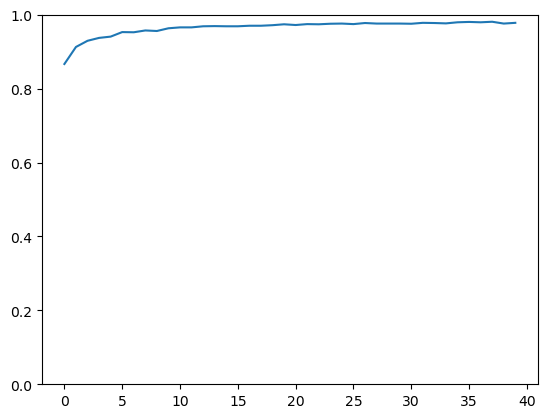

In [69]:
plt.plot(L(learn.recorder.values).itemgot(2), scaley=False);

La exactitud final es:

In [68]:
learn.recorder.values[-1][2]

0.9779195189476013